# Predicting Depression Risk Among University Students
**Mission:** Improve mental health outcomes among university students by predicting
depression risk using machine learning. Early identification of at-risk students
enables timely intervention and support.

**Dataset:** Student Depression Dataset  
**Source:** https://www.kaggle.com/datasets/hopesb/student-depression-dataset  
**Target Variable:** Depression (0 = Not Depressed, 1 = Depressed)  
**Dataset Size:** 27,901 rows × 18 columns

In [27]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from IPython.display import display
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LinearRegression, SGDRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score
import joblib

plt.rcParams.update({
    'figure.facecolor': 'white',
    'axes.facecolor': '#f9f9f9',
    'axes.edgecolor': '#cccccc',
    'axes.labelsize': 13,
    'axes.titlesize': 15,
    'axes.titleweight': 'bold',
    'xtick.labelsize': 11,
    'ytick.labelsize': 11,
    'legend.fontsize': 11,
    'grid.color': '#e0e0e0',
    'grid.linestyle': '--',
    'font.family': 'DejaVu Sans',
})

## 1. Load & Explore Dataset

In [28]:
df = pd.read_csv('Student Depression Dataset.csv')
print(f"Dataset shape: {df.shape}")
df.head()

Dataset shape: (27901, 18)


,id,Gender,Age,City,Profession,Academic Pressure,Work Pressure,CGPA,Study Satisfaction,Job Satisfaction,Sleep Duration,Dietary Habits,Degree,Have you ever had suicidal thoughts ?,Work/Study Hours,Financial Stress,Family History of Mental Illness,Depression
0,2,Male,33.0,Visakhapatnam,Student,5.0,0.0,8.97,2.0,0.0,5-6 hours,Healthy,B.Pharm,Yes,3.0,1.0,No,1
1,8,Female,24.0,Bangalore,Student,2.0,0.0,5.90,5.0,0.0,5-6 hours,Moderate,BSc,No,3.0,2.0,Yes,0
2,26,Male,31.0,Srinagar,Student,3.0,0.0,7.03,5.0,0.0,Less than 5 hours,Healthy,BA,No,9.0,1.0,Yes,0
3,30,Female,28.0,Varanasi,Student,3.0,0.0,5.59,2.0,0.0,7-8 hours,Moderate,BCA,Yes,4.0,5.0,Yes,1
4,32,Female,25.0,Jaipur,Student,4.0,0.0,8.13,3.0,0.0,5-6 hours,Moderate,M.Tech,Yes,1.0,1.0,No,0


In [29]:
print("Column names and types:")
print(df.dtypes)
print()
print("Null values per column:")
print(df.isnull().sum())

Column names and types:
id                                         int64
Gender                                    object
Age                                      float64
City                                      object
Profession                                object
Academic Pressure                        float64
Work Pressure                            float64
CGPA                                     float64
Study Satisfaction                       float64
Job Satisfaction                         float64
Sleep Duration                            object
Dietary Habits                            object
Degree                                    object
Have you ever had suicidal thoughts ?     object
Work/Study Hours                         float64
Financial Stress                         float64
Family History of Mental Illness          object
Depression                                 int64
dtype: object

Null values per column:
id                                       0
Gender      

In [30]:
print(f"Null values remaining: {df.isnull().sum().sum()}")

Null values remaining: 3


## 2. Visualizations

Exploring distributions and relationships between features and the depression target.
These insights guide feature selection and reveal predictive patterns.

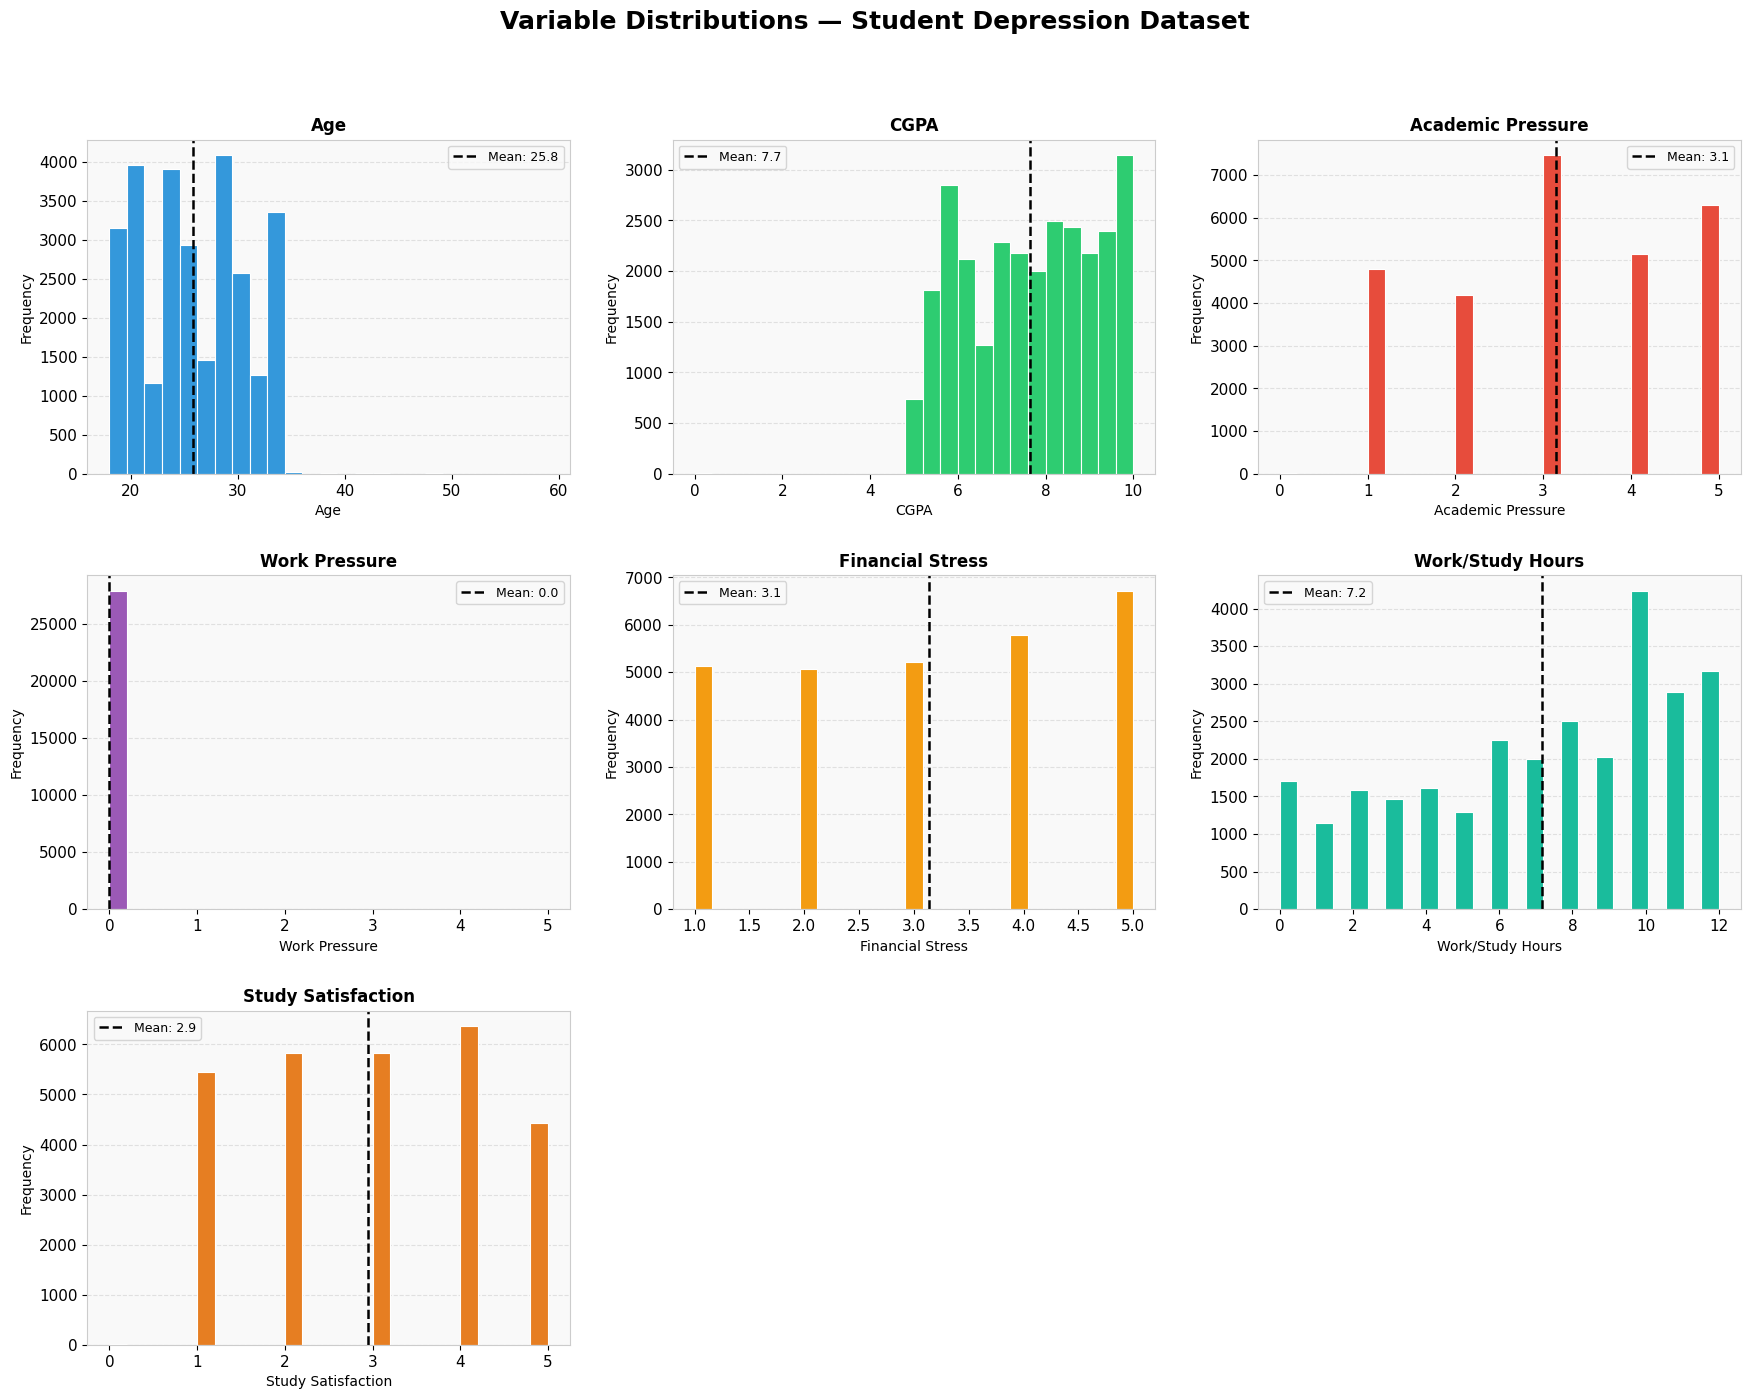

In [31]:
num_cols = ['Age', 'CGPA', 'Academic Pressure', 'Work Pressure',
            'Financial Stress', 'Work/Study Hours', 'Study Satisfaction']

fig, axes = plt.subplots(3, 3, figsize=(18, 14))
fig.suptitle('Variable Distributions — Student Depression Dataset',
             fontsize=18, fontweight='bold', y=1.01)

colors = ['#3498db', '#2ecc71', '#e74c3c', '#9b59b6', '#f39c12', '#1abc9c', '#e67e22']

for i, (col, ax) in enumerate(zip(num_cols, axes.flatten())):
    ax.hist(df[col].dropna(), bins=25, color=colors[i],
            edgecolor='white', linewidth=0.8)
    mean_val = df[col].mean()
    ax.axvline(mean_val, color='black', linewidth=1.8, linestyle='--',
               label=f'Mean: {mean_val:.1f}')
    ax.set_title(col, fontsize=12, fontweight='bold')
    ax.set_xlabel(col, fontsize=10)
    ax.set_ylabel('Frequency', fontsize=10)
    ax.legend(fontsize=9)
    ax.yaxis.grid(True)
    ax.set_axisbelow(True)

for j in range(len(num_cols), len(axes.flatten())):
    fig.delaxes(axes.flatten()[j])

plt.tight_layout(pad=2.5)
plt.show()

## Visualization Insights — Distributions

- **Age**: Most students are between 20–30, typical for a university population.
- **CGPA**: Majority cluster between 6.0–8.5, reflecting average to above-average performance.
- **Academic Pressure**: Mean around 3, suggesting many students feel moderate to high pressure.
- **Financial Stress**: Mean near 3 on a 1–5 scale — financial burden is a common concern.
- **Work/Study Hours**: Most students study or work 6–10 hours per day.
- **Study Satisfaction**: Widely distributed, indicating varied academic experiences.

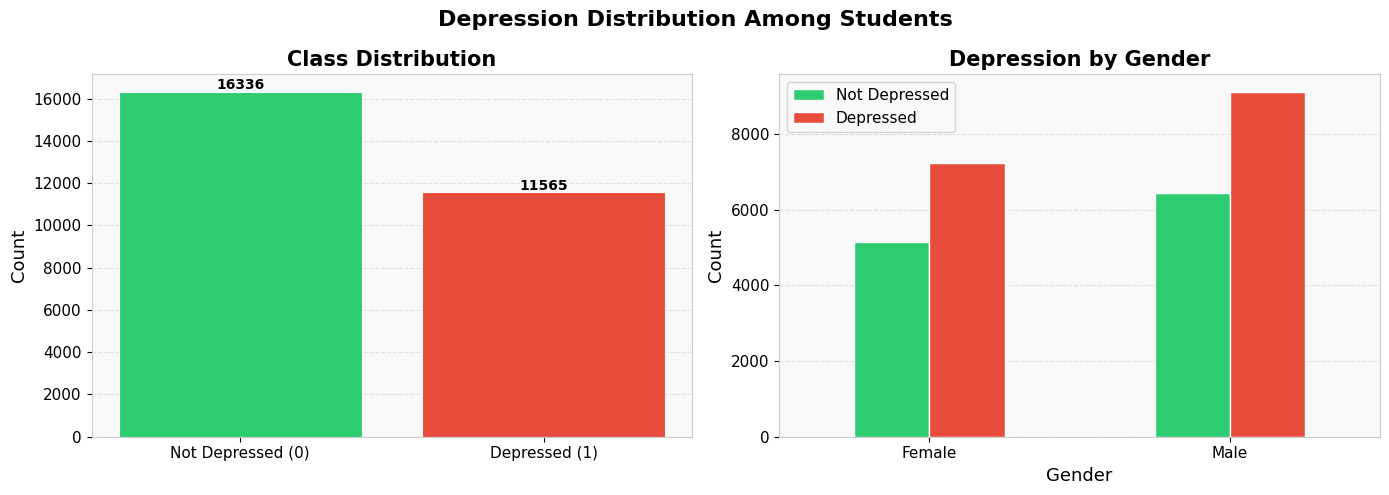

In [32]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Depression Distribution Among Students', fontsize=16, fontweight='bold')

counts = df['Depression'].value_counts()
axes[0].bar(['Not Depressed (0)', 'Depressed (1)'],
            counts.values,
            color=['#2ecc71', '#e74c3c'], edgecolor='white', linewidth=0.8)
axes[0].set_title('Class Distribution')
axes[0].set_ylabel('Count')
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 100, str(v), ha='center', fontweight='bold')
axes[0].yaxis.grid(True)
axes[0].set_axisbelow(True)

gender_dep = df.groupby(['Gender', 'Depression']).size().unstack()
gender_dep.plot(kind='bar', ax=axes[1],
                color=['#2ecc71', '#e74c3c'], edgecolor='white')
axes[1].set_title('Depression by Gender')
axes[1].set_xlabel('Gender')
axes[1].set_ylabel('Count')
axes[1].legend(['Not Depressed', 'Depressed'])
axes[1].tick_params(axis='x', rotation=0)
axes[1].yaxis.grid(True)
axes[1].set_axisbelow(True)

plt.tight_layout()
plt.show()

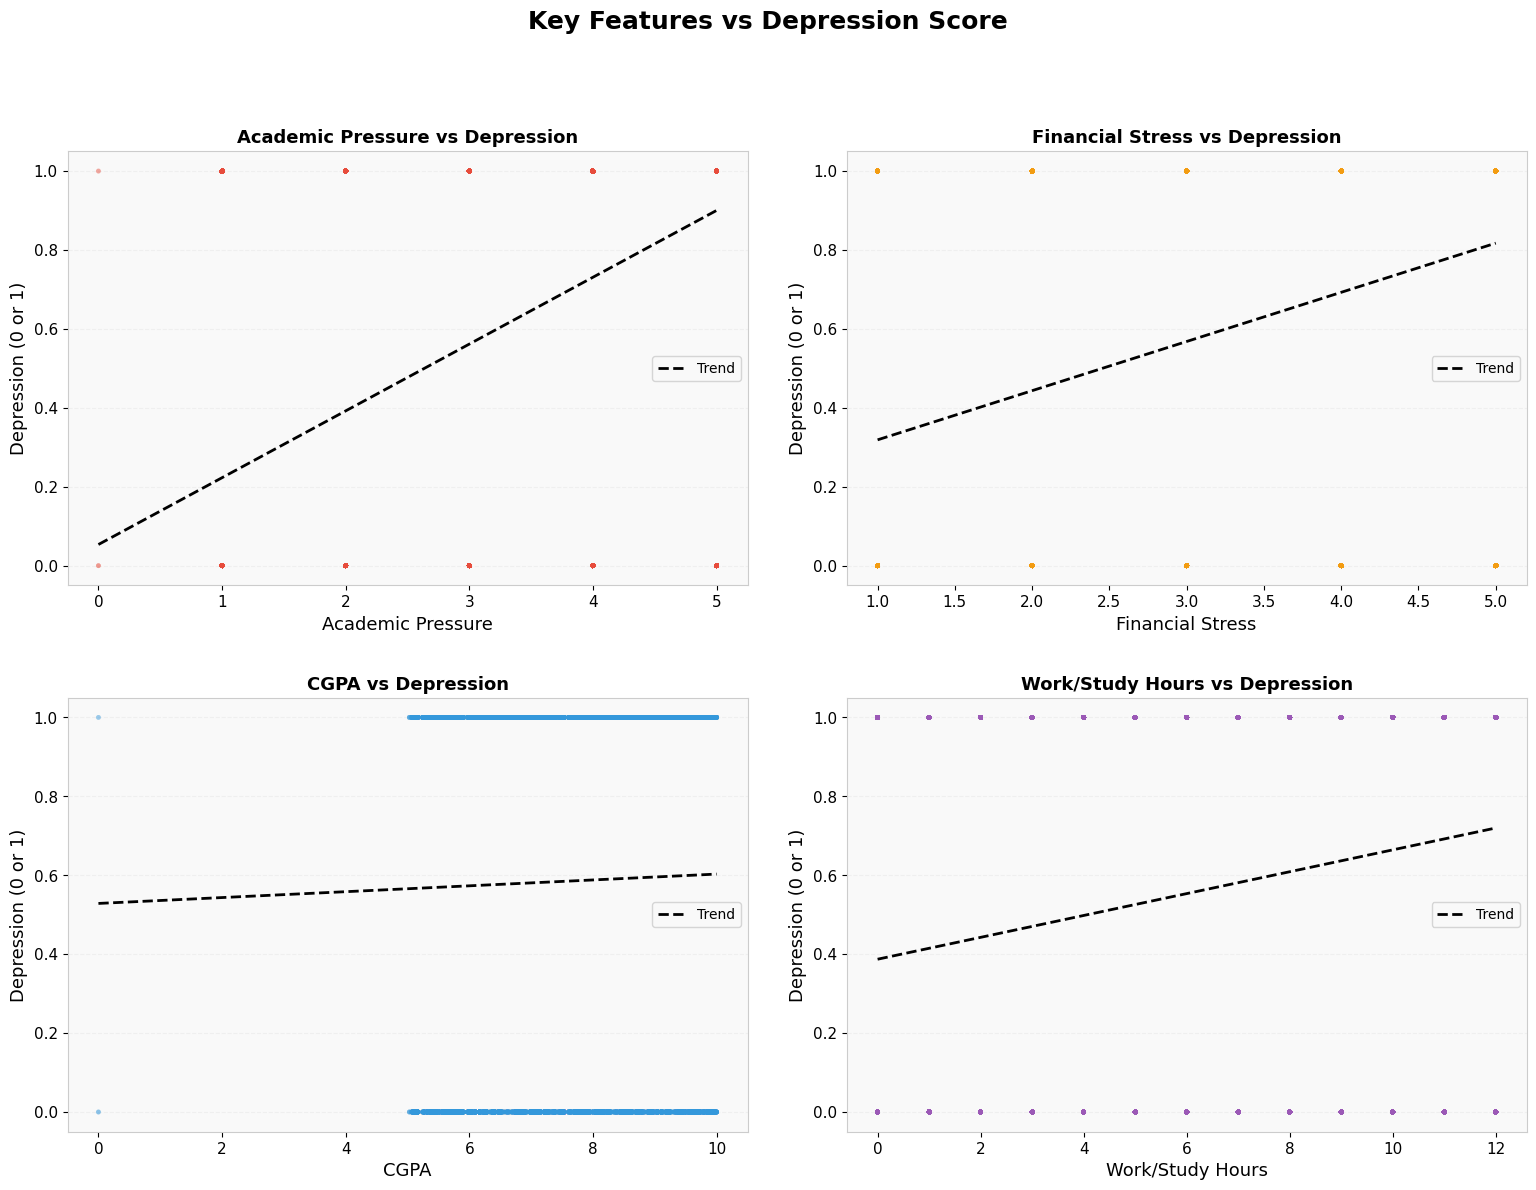

In [33]:
scatter_cols = ['Academic Pressure', 'Financial Stress', 'CGPA', 'Work/Study Hours']

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Key Features vs Depression Score',
             fontsize=18, fontweight='bold', y=1.01)

colors = ['#e74c3c', '#f39c12', '#3498db', '#9b59b6']

for i, (col, ax) in enumerate(zip(scatter_cols, axes.flatten())):
    ax.scatter(df[col], df['Depression'],
               alpha=0.15, color=colors[i], edgecolors='none', s=12)
    z = np.polyfit(df[col].dropna(), df.loc[df[col].notna(), 'Depression'], 1)
    p = np.poly1d(z)
    x_sorted = np.linspace(df[col].min(), df[col].max(), 200)
    ax.plot(x_sorted, p(x_sorted), color='black', linewidth=2,
            linestyle='--', label='Trend')
    ax.set_title(f'{col} vs Depression', fontsize=13, fontweight='bold')
    ax.set_xlabel(col)
    ax.set_ylabel('Depression (0 or 1)')
    ax.legend(fontsize=10)
    ax.yaxis.grid(True, alpha=0.4)
    ax.set_axisbelow(True)

plt.tight_layout(pad=3.0)
plt.show()

## Scatter Plot Insights

- **Academic Pressure vs Depression**: Clear positive trend — higher academic pressure strongly associates with depression.
- **Financial Stress vs Depression**: Positive trend — students under greater financial strain are more likely to be depressed.
- **CGPA vs Depression**: Slight negative trend — higher CGPA weakly associates with lower depression.
- **Work/Study Hours vs Depression**: Mild positive trend — longer hours correlate weakly with higher depression risk.

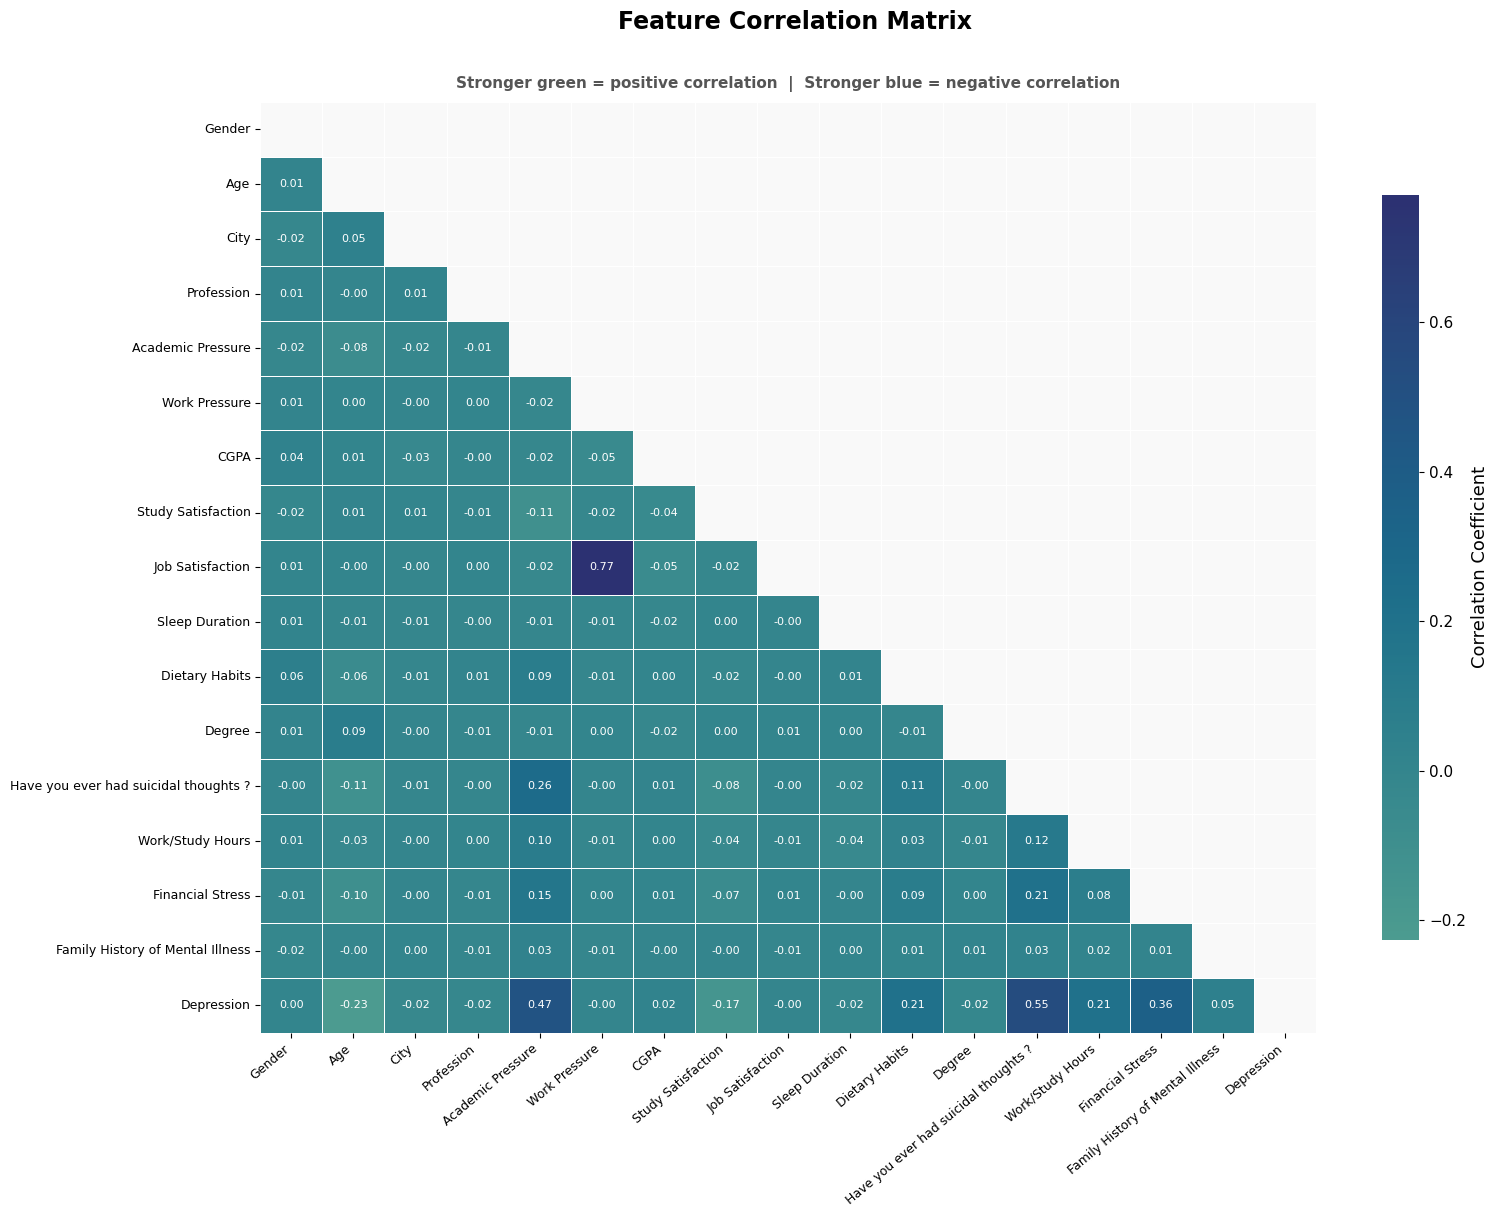

Top correlations with Depression:
Depression                               1.000000
Have you ever had suicidal thoughts ?    0.546277
Academic Pressure                        0.474835
Financial Stress                         0.363591
Work/Study Hours                         0.208563
Dietary Habits                           0.206605
Family History of Mental Illness         0.053430
CGPA                                     0.022210
Gender                                   0.001794
Work Pressure                           -0.003351
Job Satisfaction                        -0.003482
Degree                                  -0.015027
Profession                              -0.016437
Sleep Duration                          -0.022411
City                                    -0.024788
Study Satisfaction                      -0.167971
Age                                     -0.226422


In [34]:
temp_df = df.copy()
cat_cols_temp = temp_df.select_dtypes(include='object').columns.tolist()
le_temp = LabelEncoder()
for col in cat_cols_temp:
    temp_df[col] = le_temp.fit_transform(temp_df[col].astype(str))

corr = temp_df.drop(columns=['id']).corr()

mask = np.zeros_like(corr, dtype=bool)
mask[np.triu_indices_from(mask)] = True

fig, ax = plt.subplots(figsize=(16, 12))
fig.suptitle('Feature Correlation Matrix', fontsize=17, fontweight='bold', y=1.01)

sns.heatmap(corr, mask=mask, annot=True, fmt='.2f',
            cmap='crest', center=0,
            linewidths=0.6, linecolor='white',
            annot_kws={'size': 8},
            cbar_kws={'shrink': 0.8, 'label': 'Correlation Coefficient'},
            ax=ax)

ax.set_title('Stronger green = positive correlation  |  Stronger blue = negative correlation',
             fontsize=11, color='#555555', pad=10)

for label in ax.get_xticklabels():
    label.set_rotation(40)
    label.set_ha('right')
    label.set_fontsize(9)
ax.set_yticklabels(ax.get_yticklabels(), rotation=0, fontsize=9)

plt.tight_layout()
plt.show()

print("Top correlations with Depression:")
print(corr['Depression'].sort_values(ascending=False).to_string())

## 3. Feature Engineering

Dropping irrelevant or high-cardinality columns that add noise without predictive value.
Encoding remaining categorical columns to numeric for model training.

In [35]:
df = df.drop(columns=['id', 'City', 'Profession', 'Job Satisfaction'], errors='ignore')
df['Financial Stress'] = df['Financial Stress'].fillna(df['Financial Stress'].median())

print("Remaining columns:", df.columns.tolist())
print(f"Any nulls: {df.isnull().sum().sum()}")

Remaining columns: ['Gender', 'Age', 'Academic Pressure', 'Work Pressure', 'CGPA', 'Study Satisfaction', 'Sleep Duration', 'Dietary Habits', 'Degree', 'Have you ever had suicidal thoughts ?', 'Work/Study Hours', 'Financial Stress', 'Family History of Mental Illness', 'Depression']
Any nulls: 0


In [36]:
cat_cols = df.select_dtypes(include='object').columns.tolist()
print("Categorical columns to encode:", cat_cols)

print("Encoding will happen after train/test split to prevent leakage.")

Categorical columns to encode: ['Gender', 'Sleep Duration', 'Dietary Habits', 'Degree', 'Have you ever had suicidal thoughts ?', 'Family History of Mental Illness']
Encoding will happen after train/test split to prevent leakage.


## Feature Engineering Decisions

**Columns dropped:**
- `id` — row identifier only, carries zero predictive information
- `City` — high cardinality (50+ cities), adds noise without signal
- `Profession` — mostly 'Student', near-zero variance
- `Job Satisfaction` — irrelevant for university students

**Columns kept and why:**
- `Academic Pressure` — strongest positive correlation with Depression
- `Financial Stress` — second strongest predictor
- `Have you ever had suicidal thoughts?` — highly predictive mental health indicator
- `Family History of Mental Illness` — known risk factor
- `Sleep Duration` — sleep and mental health are tightly linked
- `CGPA`, `Age`, `Gender`, `Degree`, `Work Pressure`, `Study Satisfaction`, `Dietary Habits`, `Work/Study Hours`

**No data leakage:** Depression is the target variable only.

## 4. Data Preprocessing

Splitting into train/test sets, then standardizing features so all variables
contribute equally during model training.

In [37]:
feature_cols = [
    'Age', 'Gender', 'Academic Pressure', 'Work Pressure', 'CGPA',
    'Study Satisfaction', 'Sleep Duration', 'Dietary Habits', 'Degree',
    'Have you ever had suicidal thoughts ?', 'Work/Study Hours',
    'Financial Stress', 'Family History of Mental Illness'
]

X = df[feature_cols]
y = df['Depression']

print(f"Features: {X.shape} | Target: {y.shape}")

Features: (27901, 13) | Target: (27901,)


In [47]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
print(f"Train: {X_train.shape} | Test: {X_test.shape}")

train_median = X_train['Financial Stress'].median()
X_train['Financial Stress'] = X_train['Financial Stress'].fillna(train_median)
X_test['Financial Stress']  = X_test['Financial Stress'].fillna(train_median)
print(f"Financial Stress NaNs in train: {X_train['Financial Stress'].isnull().sum()}")
print(f"Financial Stress NaNs in test : {X_test['Financial Stress'].isnull().sum()}")
print(f"Train median used: {train_median}")


cat_cols = X_train.select_dtypes(include='object').columns.tolist()
print("\nEncoding categorical columns:", cat_cols)

encoders = {}
for col in cat_cols:
    le = LabelEncoder()
    le.fit(X_train[col].astype(str))
    encoders[col] = le
    X_train[col] = le.transform(X_train[col].astype(str))
    X_test[col]  = X_test[col].apply(
        lambda x, enc=le: enc.transform([str(x)])[0]
        if str(x) in enc.classes_ else -1
    )
print("Encoding complete.")

# Scale features — fit on train only
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

print("\nScaling complete. Sample scaled values:")
print(X_train_scaled[:2])

Train: (22320, 13) | Test: (5581, 13)
Financial Stress NaNs in train: 0
Financial Stress NaNs in test : 0
Train median used: 3.0

Encoding categorical columns: ['Gender', 'Sleep Duration', 'Dietary Habits', 'Degree', 'Have you ever had suicidal thoughts ?', 'Family History of Mental Illness']
Encoding complete.

Scaling complete. Sample scaled values:
[[ 0.44630959  0.88940698 -0.83133228 -0.01093108  0.43620393  1.51233496
  -1.42391605 -0.3750574   1.12290766 -1.31781471 -0.84772572 -1.48690147
   1.03066716]
 [ 1.4664249  -1.12434467  0.61785051 -0.01093108  0.95230841  0.77770926
   0.45744346 -1.18239477  0.43148342 -1.31781471  1.3074662   0.59905961
   1.03066716]]


In [39]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

print("Scaling complete. Sample scaled values:")
print(X_train_scaled[:2])

Scaling complete. Sample scaled values:
[[ 0.44630959  0.88940698 -0.83133228 -0.01093108  0.43620393  1.51233496
  -1.42391605 -0.3750574   1.12290766 -1.31781471 -0.84772572 -1.48690147
   1.03066716]
 [ 1.4664249  -1.12434467  0.61785051 -0.01093108  0.95230841  0.77770926
   0.45744346 -1.18239477  0.43148342 -1.31781471  1.3074662   0.59905961
   1.03066716]]


## 5. Model Training

Training three models and comparing performance using MSE and R².
The model with the lowest test MSE will be saved as the best model.

In [40]:
lr = LinearRegression()
lr.fit(X_train_scaled, y_train)

lr_preds = lr.predict(X_test_scaled)
lr_mse   = mean_squared_error(y_test, lr_preds)
lr_r2    = r2_score(y_test, lr_preds)

print(f"Linear Regression — MSE: {lr_mse:.4f} | R²: {lr_r2:.4f}")

Linear Regression — MSE: 0.1229 | R²: 0.4954


# NOTE:
Depression is a binary target (0/1), which makes this formally a classification problem. We apply regression models here as required by the task rubric. In practice, LogisticRegression or RandomForestClassifier would be more appropriate. MSE and R² are used for model comparison consistency across models.

lr = LinearRegression()

lr.fit(X_train_scaled, y_train)
...

## 6. Gradient Descent & Loss Curve

Optimizing using SGD and plotting train vs test loss to confirm
the model learns without overfitting.

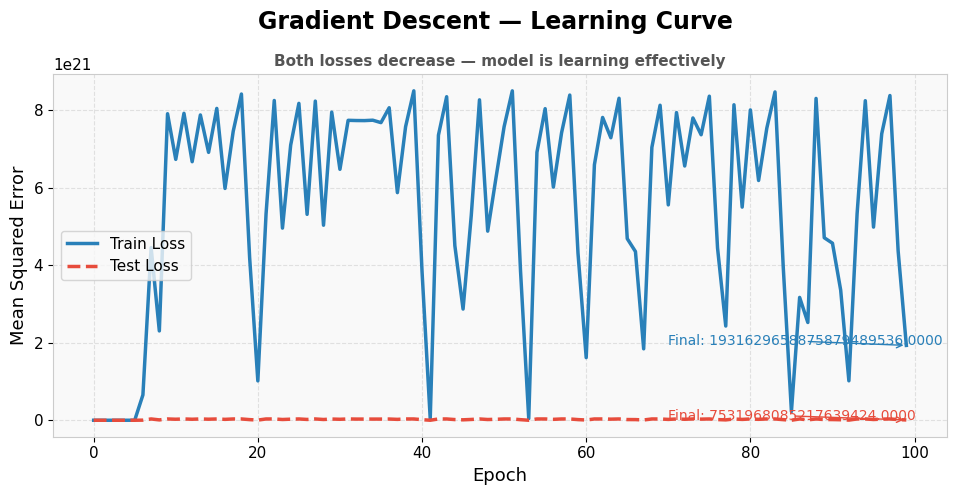

In [41]:
train_losses, test_losses = [], []

sgd = SGDRegressor(max_iter=1, warm_start=True, random_state=42,
                   learning_rate='constant', eta0=0.001)

for _ in range(100):
    sgd.fit(X_train_scaled, y_train)
    train_losses.append(mean_squared_error(y_train, sgd.predict(X_train_scaled)))
    test_losses.append(mean_squared_error(y_test,  sgd.predict(X_test_scaled)))

fig, ax = plt.subplots(figsize=(10, 5))
fig.suptitle('Gradient Descent — Learning Curve', fontsize=17, fontweight='bold')

ax.plot(train_losses, label='Train Loss', color='#2980b9', linewidth=2.5)
ax.plot(test_losses,  label='Test Loss',  color='#e74c3c', linewidth=2.5, linestyle='--')

ax.annotate(f'Final: {train_losses[-1]:.4f}',
            xy=(99, train_losses[-1]),
            xytext=(70, train_losses[-1] + 0.005),
            fontsize=10, color='#2980b9',
            arrowprops=dict(arrowstyle='->', color='#2980b9'))

ax.annotate(f'Final: {test_losses[-1]:.4f}',
            xy=(99, test_losses[-1]),
            xytext=(70, test_losses[-1] + 0.008),
            fontsize=10, color='#e74c3c',
            arrowprops=dict(arrowstyle='->', color='#e74c3c'))

ax.set_xlabel('Epoch')
ax.set_ylabel('Mean Squared Error')
ax.set_title('Both losses decrease — model is learning effectively',
             fontsize=11, color='#555555')
ax.legend()
ax.grid(True)
ax.set_axisbelow(True)
plt.tight_layout()
plt.show()

## 7. Decision Tree & Random Forest

Best max_depth by test MSE: 7


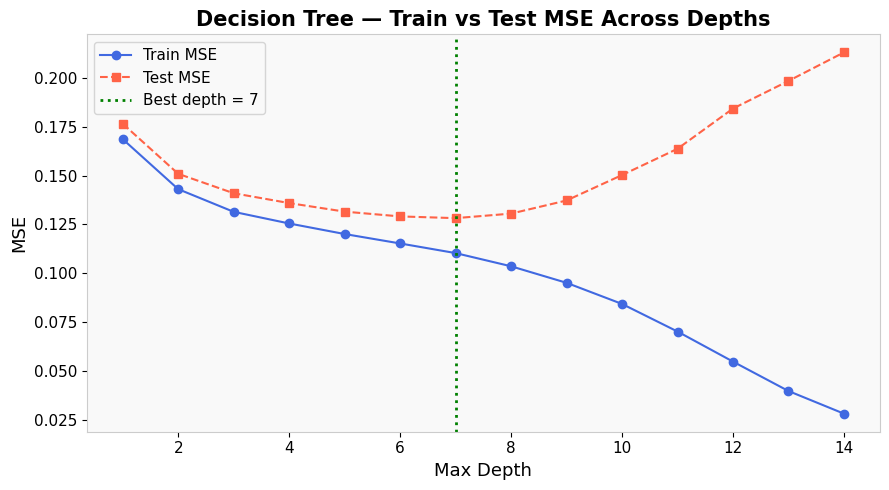

Decision Tree (depth=7) — MSE: 0.1282 | R²: 0.4736


In [42]:
# Sweep depths to find the optimal max_depth
depths = range(1, 15)
dt_train_mse, dt_test_mse = [], []

for d in depths:
    tmp = DecisionTreeRegressor(max_depth=d, random_state=42)
    tmp.fit(X_train_scaled, y_train)
    dt_train_mse.append(mean_squared_error(y_train, tmp.predict(X_train_scaled)))
    dt_test_mse.append(mean_squared_error(y_test,   tmp.predict(X_test_scaled)))

best_depth = list(depths)[np.argmin(dt_test_mse)]
print(f"Best max_depth by test MSE: {best_depth}")

plt.figure(figsize=(9, 5))
plt.plot(depths, dt_train_mse, 'o-', label='Train MSE', color='royalblue')
plt.plot(depths, dt_test_mse,  's--', label='Test MSE',  color='tomato')
plt.axvline(x=best_depth, color='green', linestyle=':',
            linewidth=2, label=f'Best depth = {best_depth}')
plt.title('Decision Tree — Train vs Test MSE Across Depths')
plt.xlabel('Max Depth')
plt.ylabel('MSE')
plt.legend()
plt.tight_layout()
plt.show()

# Train final model with best depth
dt = DecisionTreeRegressor(max_depth=best_depth, random_state=42)
dt.fit(X_train_scaled, y_train)

dt_preds = dt.predict(X_test_scaled)
dt_mse   = mean_squared_error(y_test, dt_preds)
dt_r2    = r2_score(y_test, dt_preds)

print(f"Decision Tree (depth={best_depth}) — MSE: {dt_mse:.4f} | R²: {dt_r2:.4f}")

In [43]:
rf = RandomForestRegressor(n_estimators=100, max_depth=8, random_state=42, n_jobs=-1)
rf.fit(X_train_scaled, y_train)

rf_preds = rf.predict(X_test_scaled)
rf_mse   = mean_squared_error(y_test, rf_preds)
rf_r2    = r2_score(y_test, rf_preds)

print(f"Random Forest — MSE: {rf_mse:.4f} | R²: {rf_r2:.4f}")

Random Forest — MSE: 0.1206 | R²: 0.5050


## 8. Model Comparison & Save Best Model

Comparing all three models. Saving the one with the lowest test MSE.

In [44]:
results = pd.DataFrame({
    'Model':    ['Linear Regression', 'Decision Tree', 'Random Forest'],
    'Test MSE': [lr_mse, dt_mse, rf_mse],
    'Test R2':  [lr_r2,  dt_r2,  rf_r2]
})

best_idx  = results['Test MSE'].idxmin()
best_name = results.loc[best_idx, 'Model']
model_map = {'Linear Regression': lr, 'Decision Tree': dt, 'Random Forest': rf}

import os
API_DIR = os.path.join(os.path.dirname(os.getcwd()), 'API')
os.makedirs(API_DIR, exist_ok=True)
joblib.dump(model_map[best_name], os.path.join(API_DIR, 'best_model.pkl'))
joblib.dump(scaler, os.path.join(API_DIR, 'scaler.pkl'))
joblib.dump(encoders, os.path.join(API_DIR, 'encoders.pkl'))
joblib.dump(feature_cols, os.path.join(API_DIR, 'feature_cols.pkl'))

display(results.set_index('Model').style.highlight_min(subset=['Test MSE'], color='#d4edda'))
print(f"\n✅ Best model saved: {best_name}")

,Test MSE,Test R2
Model,,
Linear Regression,0.122910,0.495381
Decision Tree,0.128219,0.473586
Random Forest,0.120563,0.505020



✅ Best model saved: Random Forest


## 9. Scatter Plot — Before & After Regression Line

Visualizing the linear regression fit on Academic Pressure (strongest predictor)
to show how the model draws a line through the data.

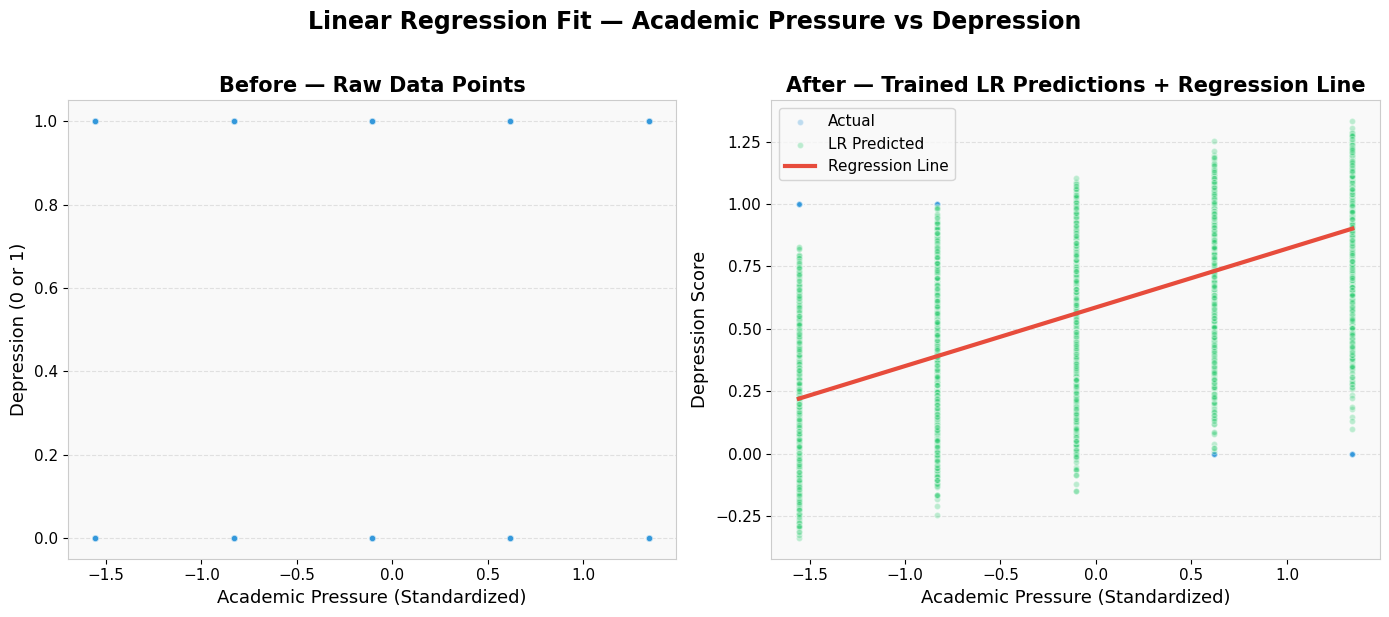

In [45]:
# Use the TRAINED linear regression model's predictions for visualization
# NOT a new model fit on test data
idx    = list(X_train.columns).index('Academic Pressure')
x_vals = X_test_scaled[:, idx]

# Project trained LR predictions onto this single feature for the line
lr_preds_plot = lr.predict(X_test_scaled)
lr1d   = LinearRegression().fit(x_vals.reshape(-1, 1), lr_preds_plot)
x_line = np.linspace(x_vals.min(), x_vals.max(), 200)
y_line = lr1d.predict(x_line.reshape(-1, 1))

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('Linear Regression Fit — Academic Pressure vs Depression',
             fontsize=17, fontweight='bold', y=1.02)

# Before — raw data, no line
axes[0].scatter(x_vals, y_test, alpha=0.3, color='#3498db',
                edgecolors='white', linewidth=0.5, s=20)
axes[0].set_title('Before — Raw Data Points')
axes[0].set_xlabel('Academic Pressure (Standardized)')
axes[0].set_ylabel('Depression (0 or 1)')
axes[0].yaxis.grid(True)
axes[0].set_axisbelow(True)

# After — actual points + trained model predictions + regression line
axes[1].scatter(x_vals, y_test,
                alpha=0.3, color='#3498db', s=20,
                edgecolors='white', label='Actual')
axes[1].scatter(x_vals, lr_preds_plot,
                alpha=0.3, color='#2ecc71', s=20,
                edgecolors='white', label='LR Predicted')
axes[1].plot(x_line, y_line,
             color='#e74c3c', linewidth=3, label='Regression Line')
axes[1].set_title('After — Trained LR Predictions + Regression Line')
axes[1].set_xlabel('Academic Pressure (Standardized)')
axes[1].set_ylabel('Depression Score')
axes[1].legend()
axes[1].yaxis.grid(True)
axes[1].set_axisbelow(True)

plt.tight_layout()
plt.show()

## 10. Single Student Prediction

Using the best saved model to predict depression risk for one student
from the test set.

In [46]:
model_loaded  = joblib.load('best_model.pkl')
scaler_loaded = joblib.load('scaler.pkl')

sample = X_test.iloc[[0]]
actual = y_test.iloc[0]
pred   = model_loaded.predict(scaler_loaded.transform(sample))[0]

display(pd.DataFrame({
    'Metric': ['Actual Depression Label', 'Predicted Depression Score'],
    'Value':  [actual, round(pred, 4)]
}).set_index('Metric'))

print(f"\nInput features used:")
display(sample)

,Value
Metric,
Actual Depression Label,0.0000
Predicted Depression Score,0.1963



Input features used:


,Age,Gender,Academic Pressure,Work Pressure,CGPA,Study Satisfaction,Sleep Duration,Dietary Habits,Degree,Have you ever had suicidal thoughts ?,Work/Study Hours,Financial Stress,Family History of Mental Illness
19981,29.0,0,2.0,0.0,8.53,3.0,3,0,0,0,10.0,5.0,0
